In [1]:
import anndata
import torch
import stPlus

import squidpy as sq
import numpy as np
import scanpy as sc
import pandas as pd

from scipy import sparse
from sklearn.model_selection import KFold
from transpa.eval_util import calc_corr
from transpa.util import expTransImp, leiden_cluster, compute_autocorr, expLocImp
from benchmark import SpaGE_impute, Tangram_impute
import warnings
from sklearn.preprocessing import MinMaxScaler
torch.autograd.detect_anomaly()
warnings.filterwarnings('ignore')

seed = 10
device = torch.device("cuda:3") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
spatial_df_file = '../../data/ST/osmFISH/osmFISH_df.csv'
spatial_loom_file = '../../data/ST/osmFISH/osmFISH_SScortex_mouse_all_cells.loom'

VISp_adata = sc.read("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_exon-matrix.csv").T
genes = pd.read_csv("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_genes-rows.csv", header=0,sep=',')
VISp_meta = pd.read_csv("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_samples-columns.csv", header=0,sep=',')

VISp_adata.obs = VISp_meta
VISp_adata.var_names = genes.gene_symbol

sc.pp.filter_genes(VISp_adata, min_cells=10)
VISp_adata = VISp_adata[(VISp_adata.obs['class'] != 'No Class') & (VISp_adata.obs['class'] != 'Low Quality')]
classes, ct_list = leiden_cluster(VISp_adata)
cls_key = 'leiden'
VISp_adata.obs[cls_key] = classes
sc.pp.normalize_total(VISp_adata)
sc.pp.log1p(VISp_adata)
VISp_adata


AnnData object with n_obs × n_vars = 14249 × 34617
    obs: 'sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermed

In [ ]:
osmFISH = sc.read_loom(spatial_loom_file)
osmFISH = osmFISH[~np.isin(osmFISH.obs.Region, ['Excluded', 'Hippocampus', 'Internal Capsule Caudoputamen','Ventricle', 'White matter'])].copy()
raw_spatial_df  = pd.read_csv(spatial_df_file)
osmFISH.X = raw_spatial_df.values


raw_scrna_df    = pd.DataFrame(VISp_adata.X, columns=VISp_adata.var_names)
adata_scrna   = VISp_adata

raw_shared_gene = np.intersect1d(raw_spatial_df.columns, raw_scrna_df.columns)
raw_spatial_df.shape, raw_scrna_df.shape, raw_shared_gene.shape

((3405, 33), (14249, 34617), (33,))

In [ ]:
osmFISH.obsm['spatial'] = MinMaxScaler().fit_transform(np.hstack([osmFISH.obs.X.values.reshape(-1,1), osmFISH.obs.Y.values.reshape(-1,1)]))


In [ ]:
sc_expr = sparse.coo_matrix(raw_scrna_df[raw_shared_gene].values)
sp_expr = raw_spatial_df[raw_shared_gene].values
loc     = osmFISH.obsm['spatial']
sc_loc = expLocImp(sc_expr, 
            sp_expr,
            loc,
            n_neighbors=8,
            l_kernel=2,
            autocorr_method='moranI',
            mapping_lowdim=128,
            lr=1e-3, weight_decay=1e-3, n_epochs=2000,
            device=device,
            seed=seed
            )            

[KeOps] Generating code for formula ArgKMin_Reduction(Sum((Var(0,2,0)-Var(1,2,1))**2),0) ... OK
tensor([0.1190, 0.1688, 0.1061, 0.2113, 0.1341, 0.1874, 0.4114, 0.1311, 0.0908,
        0.2645, 0.1584, 0.1052, 0.0812, 0.3817, 0.1602, 0.1161, 0.4225, 0.4313,
        0.1093, 0.0967, 0.1107, 0.3126, 0.0847, 0.7171, 0.1661, 0.1085, 0.1613,
        0.5033, 0.2390, 0.0844, 0.0916, 0.0949, 0.1415], device='cuda:3')


[LocImp] Epoch: 2000/2000, loss: 0.070774: 100%|██████████| 2000/2000 [01:13<00:00, 27.20it/s]


[ 0.01574319  0.01538152  0.01025629  0.00377237  0.01393719  0.02043377
  0.03045619  0.01871414  0.01431687  0.02102467  0.00143904  0.00955174
  0.03441321  0.01308326 -0.00093812  0.00969813  0.02411021  0.03017509
  0.01233879  0.00362317 -0.0016692   0.0172629   0.01794943  0.04665522
  0.00728968  0.03275163  0.00676028  0.03466525  0.03223211  0.00478646
  0.01072383  0.02034757  0.02230535]


In [ ]:
np.unique(VISp_adata.obs['class'], return_counts=True)

(array(['Endothelial', 'GABAergic', 'Glutamatergic', 'Non-Neuronal'],
       dtype=object),
 array([ 181, 6125, 7366,  577]))

(array([   7.,   19.,   72.,  279., 1383., 4940., 2811., 4661.,   70.,
          7.]), array([-2.0623548 , -1.6583297 , -1.2543048 , -0.8502797 , -0.44625464,
       -0.04222959,  0.36179546,  0.7658205 ,  1.1698456 ,  1.5738705 ,
        1.9778956 ], dtype=float32), <BarContainer object of 10 artists>)


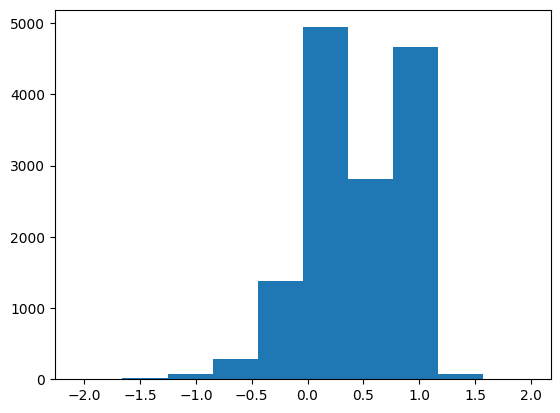

(array([   8.,   19.,   82.,  352., 3811., 4234., 4584., 1129.,   25.,
           5.]),
 array([-2.2073164 , -1.7509676 , -1.2946188 , -0.8382701 , -0.38192138,
         0.07442737,  0.53077614,  0.98712486,  1.4434736 ,  1.8998224 ,
         2.3561711 ], dtype=float32),
 <BarContainer object of 10 artists>)

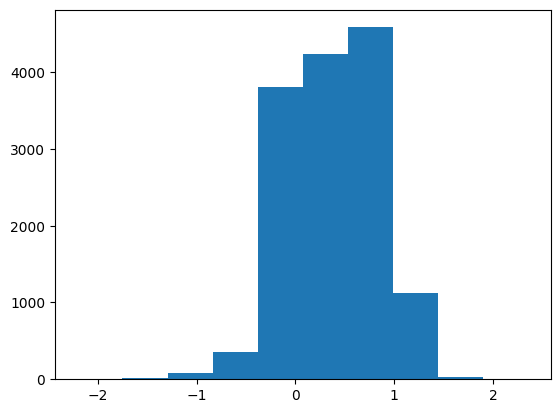

In [ ]:
from matplotlib import pyplot as plt
print(plt.hist(sc_loc[:, 0])); plt.show(); plt.hist(sc_loc[:, 1])

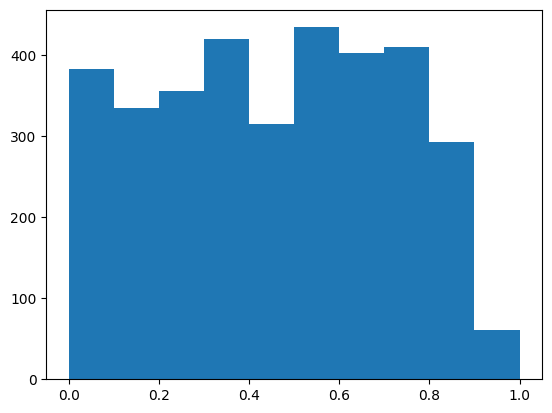

(array([ 48.,  69., 162., 279., 531., 706., 628., 499., 339., 144.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

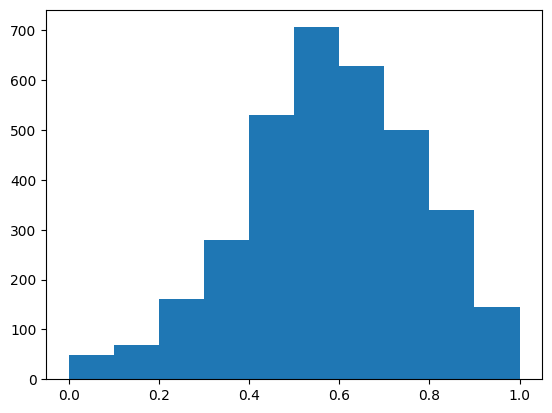

In [ ]:
from matplotlib import pyplot as plt
plt.hist(osmFISH.obsm['spatial'][:, 0]); plt.show(); plt.hist(osmFISH.obsm['spatial'][:, 1])

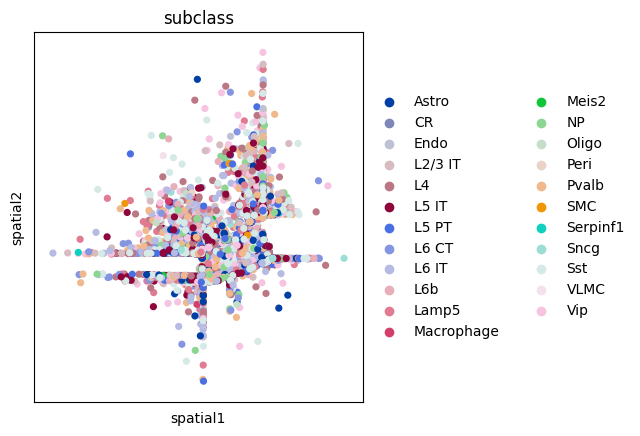

In [ ]:
VISp_adata.obsm["spatial"] = sc_loc # MinMaxScaler().fit_transform(sc_loc)
sc.pl.spatial(VISp_adata, basis="spatial", color="subclass", spot_size=0.1)

In [ ]:
osmFISH

AnnData object with n_obs × n_vars = 3405 × 33
    obs: 'ClusterID', 'ClusterName', 'Region', 'Total_molecules', 'Valid', 'X', 'Y', '_tSNE_1', '_tSNE_2', 'size_pix', 'size_um2'
    var: 'Fluorophore', 'Hybridization'
    obsm: 'spatial'

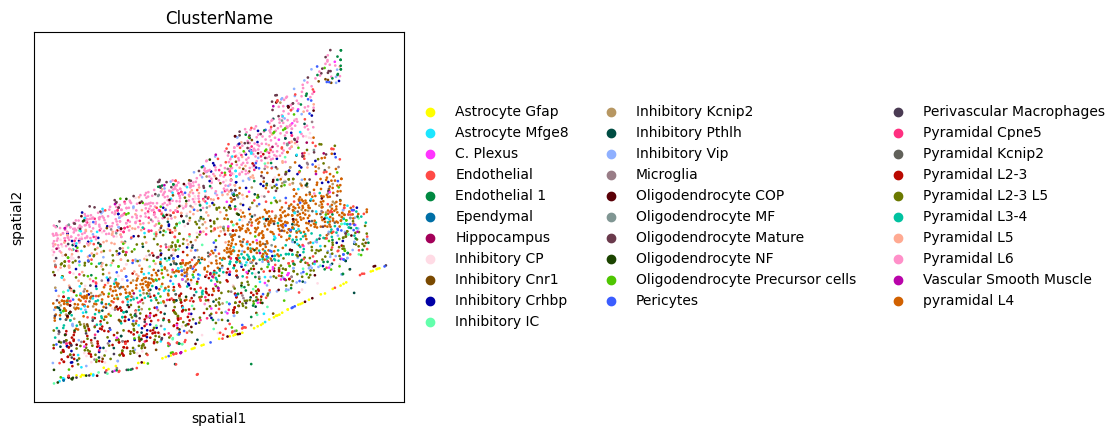

In [ ]:
sc.pl.spatial(osmFISH, color="ClusterName", basis="spatial", spot_size=0.008)